In [160]:
!pip install pydotplus


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [161]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [162]:
df=pd.read_csv("titanic.csv")

In [163]:
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [164]:
df["Age"]=df["Age"].fillna(df["Age"].median())
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [165]:
input_df=df[["Pclass","Sex","Age","Fare"]]
target_df=df[["Survived"]]

In [166]:
from sklearn.preprocessing import LabelEncoder
le_Sex=LabelEncoder()
input_df["Sex"]=le_Sex.fit_transform(input_df["Sex"])
display(input_df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_4288\140320602.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df["Sex"]=le_Sex.fit_transform(input_df["Sex"])


,Pclass,Sex,Age,Fare
0,3,1,22.0,7.2500
1,1,0,38.0,71.2833
2,3,0,26.0,7.9250
3,1,0,35.0,53.1000
4,3,1,35.0,8.0500


In [167]:
def classify(row):
    age=row["Age"]
    if age<18:
        return "young"
    elif age<40:
        return "senior"
    else:
        return "old"
input_df["Age"]=input_df.apply(classify,axis=1)
display(input_df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_4288\4097846334.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df["Age"]=input_df.apply(classify,axis=1)


,Pclass,Sex,Age,Fare
0,3,1,senior,7.2500
1,1,0,senior,71.2833
2,3,0,senior,7.9250
3,1,0,senior,53.1000
4,3,1,senior,8.0500


In [168]:
le_Age=LabelEncoder()
input_df["Age"]=le_Age.fit_transform(input_df["Age"])
display(input_df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_4288\3478517218.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df["Age"]=le_Age.fit_transform(input_df["Age"])


,Pclass,Sex,Age,Fare
0,3,1,1,7.2500
1,1,0,1,71.2833
2,3,0,1,7.9250
3,1,0,1,53.1000
4,3,1,1,8.0500


In [169]:
def classify_fare(row):
    fare = row["Fare"]
    if fare < 100:
        return "Low"
    elif fare < 300:
        return "Med"
    else:
        return "High"
input_df["Fare"] = input_df.apply(classify_fare, axis=1)
le_fare = LabelEncoder()
input_df["Fare"] = le_fare.fit_transform(input_df["Fare"])
print(input_df.head())

   Pclass  Sex  Age  Fare
0       3    1    1     1
1       1    0    1     1
2       3    0    1     1
3       1    0    1     1
4       3    1    1     1


C:\Users\HP\AppData\Local\Temp\ipykernel_4288\420503480.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df["Fare"] = input_df.apply(classify_fare, axis=1)
C:\Users\HP\AppData\Local\Temp\ipykernel_4288\420503480.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df["Fare"] = le_fare.fit_transform(input_df["Fare"])


In [170]:
def classify_age(row):
    age = row["Age"]
    if age < 18:
        return "young"
    elif age < 40:
        return "senior"
    else:
        return "old"
input_df["Age"] = input_df.apply(classify_age, axis=1)
le_Age = LabelEncoder()
input_df["Age"] = le_Age.fit_transform(input_df["Age"])
display(input_df.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_4288\1694790803.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df["Age"] = input_df.apply(classify_age, axis=1)
C:\Users\HP\AppData\Local\Temp\ipykernel_4288\1694790803.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df["Age"] = le_Age.fit_transform(input_df["Age"])


,Pclass,Sex,Age,Fare
0,3,1,0,1
1,1,0,0,1
2,3,0,0,1
3,1,0,0,1
4,3,1,0,1


In [171]:
input_df.describe()

,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.0,891.000000
mean,2.308642,0.647587,0.0,1.052750
std,0.836071,0.477990,0.0,0.238254
min,1.000000,0.000000,0.0,0.000000
25%,2.000000,0.000000,0.0,1.000000
50%,3.000000,1.000000,0.0,1.000000
75%,3.000000,1.000000,0.0,1.000000
max,3.000000,1.000000,0.0,2.000000


In [172]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(input_df, target_df, test_size=0.3)

# Train model
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [173]:
model.predict([[3,1,1,1]])

C:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0], dtype=int64)

In [174]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.7929373996789727
Test Accuracy: 0.7798507462686567


In [175]:
from io import StringIO
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from IPython.display import Image
import pydotplus

In [176]:
print(input_df.columns)

Index(['Pclass', 'Sex', 'Age', 'Fare'], dtype='object')


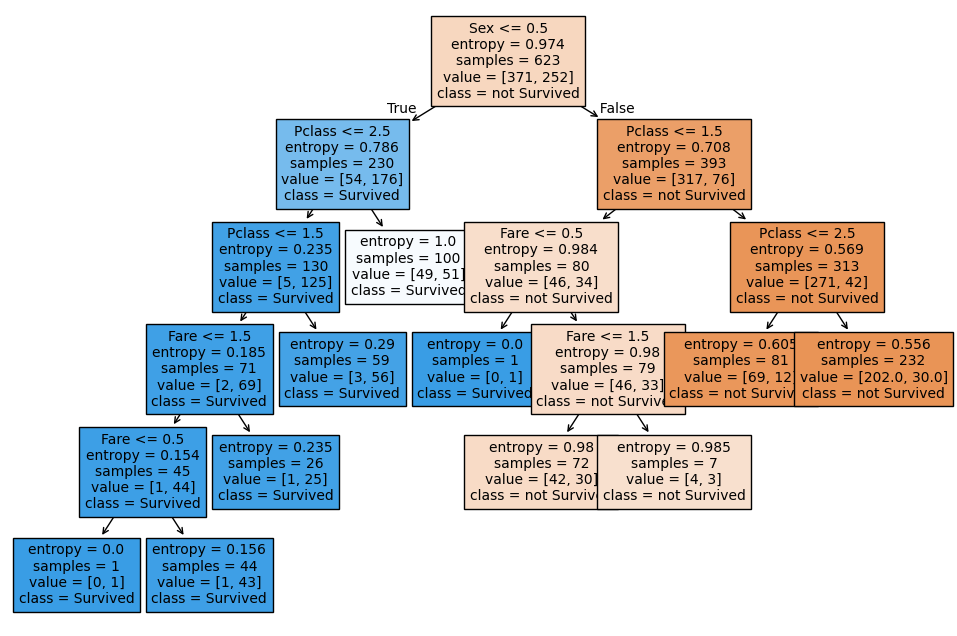

In [177]:
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=['Pclass', 'Sex', 'Age', 'Fare'], filled=True,fontsize=10,class_names=["not Survived","Survived"])
plt.show()